In [2]:
from PIL import Image
import cv2
import numpy as np 
import glob
import os
from collections import Counter
import random
import matplotlib.pyplot as plt

In [3]:
input_path = "../Data/*.tiff"
output_folder = "../Data_jpg"
files = glob.glob(input_path)
for file in files:
    img = cv2.imread(file,0)
    if img is None:
        continue
    filename = os.path.basename(file).replace(".tiff", ".jpg")
    save_path = os.path.join(output_folder, filename)

    cv2.imwrite(save_path, img)

In [4]:
print(f"Num of pic : {len(files)}")

Num of pic : 18038


In [5]:
sizes = []
for file in files:
    img = cv2.imread(file,0)
    sizes.append(img.shape)
size_counts = Counter(sizes)
print(f'the same size : {len(size_counts)}')
for size, count in size_counts.items():
    print(f"Size {size}: {count} images")

the same size : 1
Size (300, 300): 18038 images


In [6]:
output_folder = "../Data_denoised"
for file in files:
    img = cv2.imread(file,0)
    denoised = cv2.medianBlur(img, 5)
    
    filename  = os.path.basename(file).replace(".tiff", ".jpg")
    save_path = os.path.join(output_folder, filename)
    cv2.imwrite(save_path, denoised)


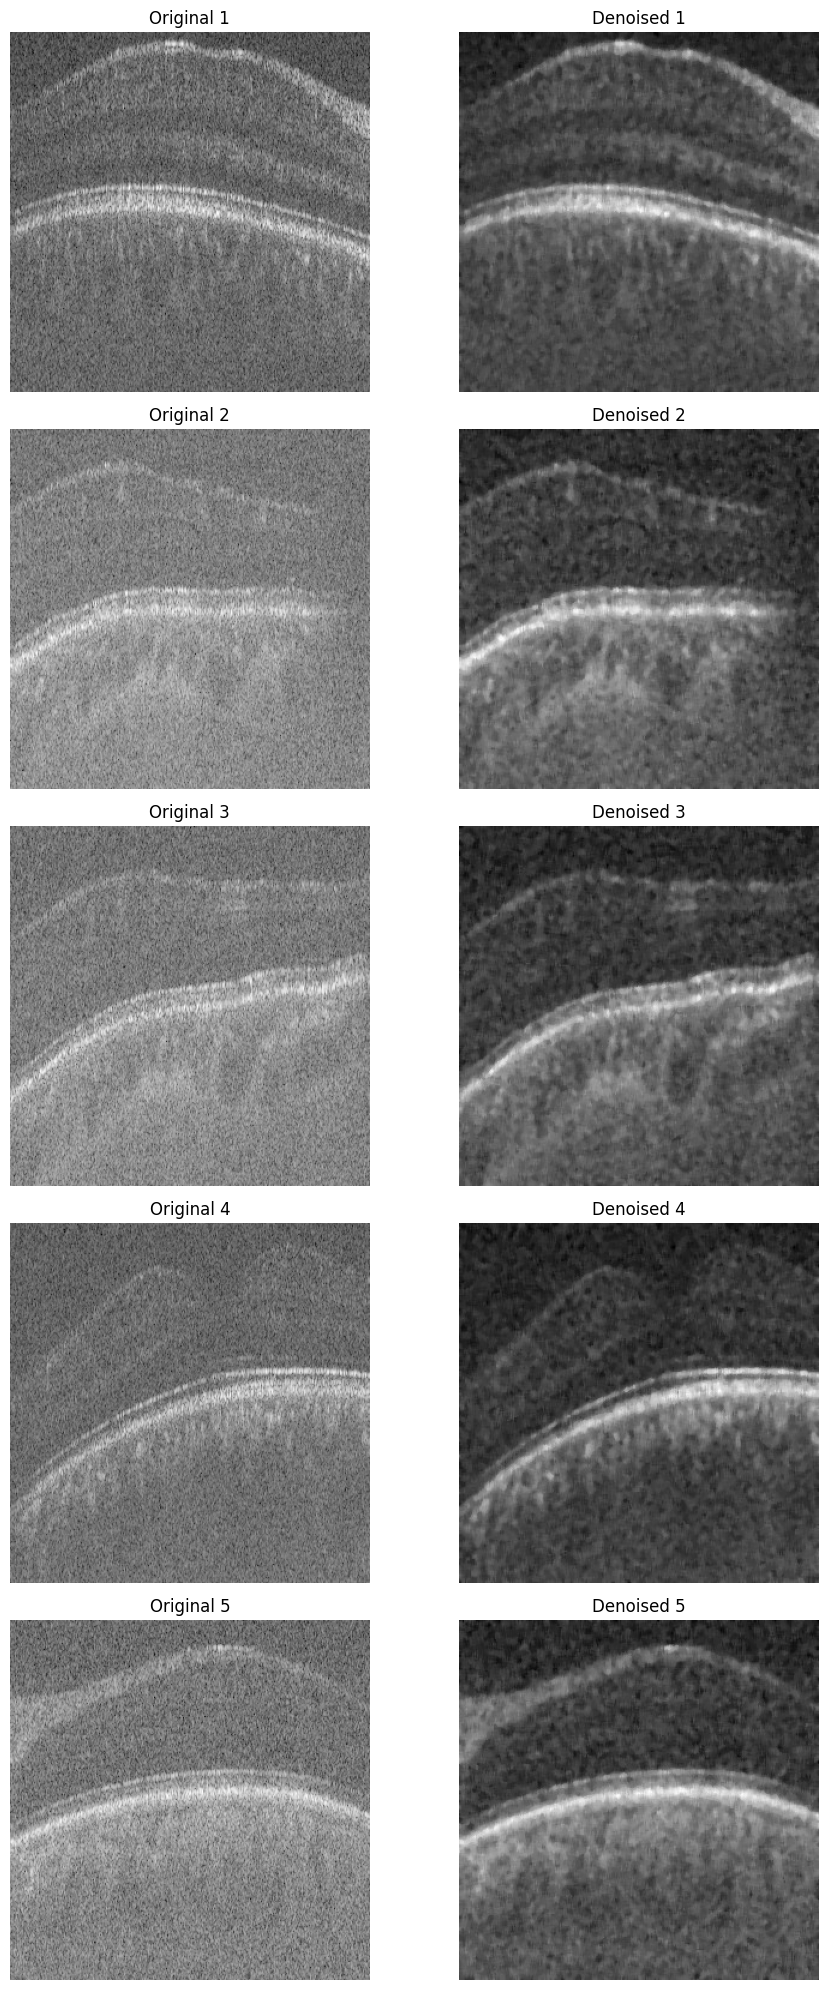

In [7]:
original_path = "../Data_jpg/*.jpg"
denoised_path = "../Data_denoised/*.jpg"
original_files = glob.glob(original_path)
denoised_files = glob.glob(denoised_path)
indices = random.sample(range(len(original_files)), 5)
fig, axes = plt.subplots(5, 2, figsize=(10, 20))
for i, idx in enumerate(indices):
    original = cv2.imread(original_files[idx], 0)
    denoised = cv2.imread(denoised_files[idx], 0)
    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis('off')
    axes[i, 1].imshow(denoised, cmap='gray')
    axes[i, 1].set_title(f"Denoised {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()